# Import data

Start by importing the file downloaded from the Georgia Secretary of State's website.

In [6]:
import pandas as pd

# Contains some code that needs to be used by other notebooks.
import sos

# 2024 election data for now
df = pd.read_json('./export-2024NovGen.json', typ='series')
#df['results']['ballotItems'] = pd.DataFrame(df['results']['ballotItems'])
df = sos.prepare_export_df(df, use_advanced=True)

df

electionDate                                           2024-11-05
electionName                            November General Election
createdAt                            2025-01-30T13:59:59.5881725Z
results         {'id': '09378a07-e6cf-4f66-be7c-ca4aa534f99a',...
localResults                                           id     ...
dtype: object

# State Senate races

In [7]:
import utils

def summarize(chamber: pd.DataFrame):
    chamber['raceStatus'] = chamber['ballotOptions'].apply(lambda x: 'Final' 
                                                           if len(x) == 1 else 'Leading')
    chamber['leadingParty'] = chamber['ballotOptions'].apply(lambda x: 
                                                            sorted(x, key=lambda y: y['voteCount'], 
                                                                    reverse=True)[0]['politicalParty'])
    chamber['changingParties'] = chamber.apply(lambda x: x['incumbentParty'] != x['leadingParty'], axis=1) 

    # Seats won
    table = pd.crosstab(chamber['leadingParty'], 
                        [chamber['raceStatus']], 
                        rownames=['leadingParty'],
                        colnames=['raceStatus'])
    table['Total'] = table['Final'] + table['Leading']
    table = table.sort_values('Total', ascending=False)
    print(table)

    # Seat changes
    changes = pd.DataFrame([], index=table.index, 
                           columns=pd.MultiIndex.from_tuples(utils.make_tuple_matrix(['Final', 'Leading'], ['Gains', 'Losses', 'Change'])))
    for prg in ['Final', 'Leading']:
        changes[(prg, 'Gains')] = [len(chamber[(chamber['changingParties']) & 
                                               (chamber['leadingParty'] == party) &
                                               (chamber['raceStatus'] == prg)])
                                               for party in table.index]
        changes[(prg, 'Losses')] = [len(chamber[(chamber['incumbentParty'] == party) & 
                                                (chamber['changingParties']) &
                                                (chamber['raceStatus'] == prg)]) 
                                                for party in table.index]
        changes[(prg, 'Change')] = changes[prg, 'Gains'] - changes[prg, 'Losses']
        #changes[(prg, 'Change')] = changes[prg, 'Change'].apply(lambda x: f'+{x}' if x > 0 else f'{x}')
        changes = changes.drop([(prg, 'Gains'), (prg, 'Losses')], axis=1)
    changes['Total', 'Change'] = changes['Final', 'Change'] + changes['Leading', 'Change']
    changes = changes.map(utils.format_delta)
    print(changes)

    # Seats changing hands
    flipped = pd.DataFrame(chamber)
    flipped = flipped[flipped['changingParties']]
    flipped = flipped.set_index('name')
    flipped = flipped.reindex(columns=['incumbentParty', 'leadingParty', 'raceStatus', 'ballotOptions'])
    flipped.columns = ['Incumbent Party', 'Leading Party', 'Race Status', 'ballotOptions']
    flipped['Leading Ballot Option'] = \
        flipped['ballotOptions'].apply(lambda x: sorted(x, key=lambda y: y['voteCount'], reverse=True)[0])
    flipped['Leading Candidate'] = \
        flipped['Leading Ballot Option'].apply(lambda x: x['name'].replace(' (Rep)', '').replace(' (Dem)', ''))
    flipped = flipped.drop(['Leading Ballot Option', 'ballotOptions'], axis=1)
    if len(flipped) > 0:
        print(flipped)

    return chamber

# Import incumbent parties data

def make_chamber_race(chamber, district):
    return f'{chamber} - District {district}'

incumbent_parties = pd.read_csv('incumbent_parties.csv')
incumbent_parties['name'] = \
incumbent_parties.apply(lambda r: make_chamber_race(r['Chamber'], r['District']), axis=1)
incumbent_parties

,Chamber,District,incumbentParty,name
0,State Senate,1,Rep,State Senate - District 1
1,State Senate,2,Dem,State Senate - District 2
2,State Senate,3,Rep,State Senate - District 3
3,State Senate,4,Rep,State Senate - District 4
4,State Senate,5,Dem,State Senate - District 5
...,...,...,...,...
245,United States House of Representatives,10,Rep,United States House of Representatives - Distr...
246,United States House of Representatives,11,Rep,United States House of Representatives - Distr...
247,United States House of Representatives,12,Rep,United States House of Representatives - Distr...
248,United States House of Representatives,13,Dem,United States House of Representatives - Distr...


In [8]:
ss: pd.DataFrame = df['results']['ballotItems']
ss = ss[ss['name'].apply(lambda x: 'State Senate' in x)]
ss = ss.join(incumbent_parties.set_index('name')['incumbentParty'], on='name')
ss = summarize(ss)

raceStatus    Final  Leading  Total
leadingParty                       
Rep              18       15     33
Dem              15        8     23
              Final Leading  Total
             Change  Change Change
leadingParty                      
Rep               0       0      0
Dem               0       0      0


# State House

In [9]:
sh: pd.DataFrame = df['results']['ballotItems']
sh = sh[sh['name'].apply(lambda x: 'State House' in x)]
sh = sh.join(incumbent_parties.set_index('name')['incumbentParty'], on='name')
sh = summarize(sh)

raceStatus    Final  Leading  Total
leadingParty                       
Rep              47       53    100
Dem              43       37     80
              Final Leading  Total
             Change  Change Change
leadingParty                      
Rep               0      +1     +1
Dem               0      -1     -1
                                              Incumbent Party Leading Party  \
name                                                                          
State House of Representatives - District 121             Dem           Rep   

                                              Race Status  \
name                                                        
State House of Representatives - District 121     Leading   

                                                    Leading Candidate  
name                                                                   
State House of Representatives - District 121  Marcus A. Wiedower (I)  


# Map dashboard

At some point, this will be dynamic and need to be taken out of the notebook.

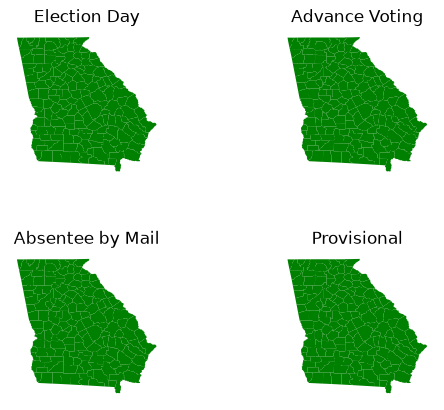

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import utils


fig, axes = plt.subplots(nrows=2, ncols=2)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
counties = utils.import_county_map()
df['localResults']['name'] = df['localResults']['name'].apply(lambda c: c.replace(' County', ''))
slots = [[0,0], [0,1], [1,0], [1,1]]
color = {
    'Not Reported': '#aaaaaa',
    'Partially Reported': '#767676',
    'Election Night Complete': '#242424',
    'Fully Reported': '#008000'
}
for x, vote_group in enumerate(sos.vote_methods):
    counties[vote_group] = df['localResults'].set_index('name')[vote_group]
    cmap = mcolors.ListedColormap([color[s] for s in counties[vote_group].unique()])
    ax = counties.plot(column=vote_group, ax=axes[*slots[x]], cmap=cmap)
    ax.set_title(vote_group)
    ax.set_axis_off()
plt.show()